In [ ]:
# check which directory i'm using
#import sys
#sys.executable

In [ ]:
# install LIANA
#!{sys.executable} -m pip install liana

In [ ]:
### Liana provides differnet statistical methods to infer ligand-receptor interactions from single cell transcriptomics
## using prior knowledge

In [5]:
## loading packages
# import liana
import liana as li
# needed for visualization and toy data
import scanpy as sc

In [6]:
## loading the data
# In the most general case, liana’s ligand-receptor methods use anndata objects with processed single-cell transcriptomics data, 
# with pre-defined cell labels (identities), to infer ligand-receptor interactions among all pairs of cell identities.
adata = sc.read_h5ad("/Users/ogjaime/Desktop/CellRank/krabd12/krabd12.h5ad")

In [7]:
adata.obs

,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,celltype
AAACCCAAGGAACTAT-1,2671,2671,4838.0,4.0,0.082679,0,MSC
AAACCCAAGGTCGTGA-1,2314,2314,3594.0,3.0,0.083472,0,MSC
AAACCCAAGTTTCAGC-1,1008,1008,1310.0,6.0,0.458015,1,RPC
AAACCCACACTCACTC-1,2519,2519,3784.0,5.0,0.132135,4,NPC
AAACCCATCAACGTGT-1,2844,2843,4762.0,12.0,0.251995,1,RPC
...,...,...,...,...,...,...,...
TTTGTTGGTTCGAAGG-1,4278,4278,10387.0,183.0,1.761818,3,SMPC
TTTGTTGTCAGACCCG-1,2107,2107,3410.0,0.0,0.000000,0,MSC
TTTGTTGTCATGTCAG-1,2031,2031,2898.0,10.0,0.345066,1,RPC
TTTGTTGTCGGCACTG-1,3127,3127,5322.0,8.0,0.150319,1,RPC


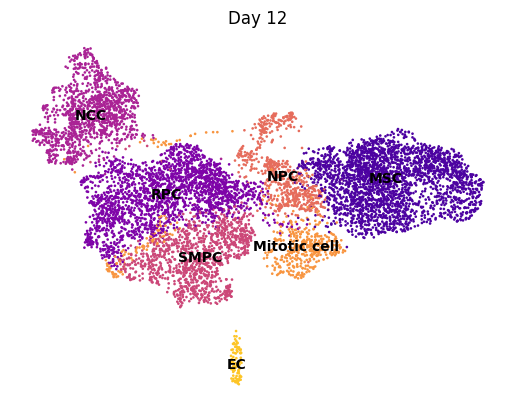

In [8]:
sc.pl.umap(adata, color='celltype', title='Day 12', frameon=False, legend_loc='on data')

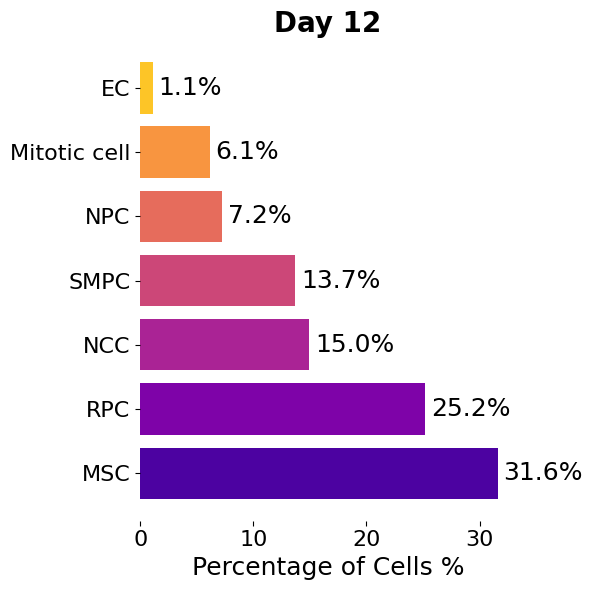

In [9]:
import matplotlib.pyplot as plt
import scanpy as sc

# Ensure cluster counts are sorted
cluster_counts = adata.obs['celltype'].value_counts(normalize=True) * 100
cluster_counts = cluster_counts.sort_index()  # ensures consistent order

# Get colors from your UMAP palette
cluster_colors_dict = dict(zip(adata.obs['celltype'].cat.categories, adata.uns['celltype_colors']))
colors = [cluster_colors_dict[ct] for ct in cluster_counts.index]

# Create horizontal bar plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.barh(
    cluster_counts.index.astype(str),
    cluster_counts,
    color=colors  # matching UMAP colors
)

# Add percentage labels
for i, val in enumerate(cluster_counts.values):
    ax.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=18)

# Add labels and title
ax.set_xlabel('Percentage of Cells %', fontsize=18)
#ax.set_ylabel('Cell Type', fontsize=16)
ax.set_title('Day 12', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=16)

# --- Remove all spines (boxed border) ---
for spine in ax.spines.values():
    spine.set_visible(False)


plt.tight_layout()
plt.show()


In [ ]:
### renaming categories
#adata.obs['celltype'] = adata.obs['celltype'].cat.rename_categories({
    #'CGC': 'MSC', 
    #'MSC': 'SclPC',
    #'MC': 'CPC',
    #'Mitotic MC': 'P_CPC',
#})
#adata.obs['celltype'].cat.categories

In [ ]:
## Use liana with all features (genes) for which we have enough counts
## for that reason check where your expression data lives
#adata.X   # usually the main processed matrix

In [ ]:
#adata.raw # optional, often used to store original normalized counts

In [ ]:
# the adata.raw.X contains the log1p-transformed counts, unscaled, which is what LIANA expects

In [ ]:
# Use the expression matrix stored in adata.raw
#expr_matrix = adata.raw.X

In [10]:
adata.raw.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 23386976 stored elements and shape (8307, 21816)>

In [11]:
# methods
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [12]:
# import liana's rank_aggregate
# rank_aggregate combines the scores of multiple methods
from liana.mt import rank_aggregate

In [13]:
# Get an aggregate of ligand-receptor scores from multiple methods.
?rank_aggregate.__call__

Signature:
rank_aggregate.__call__(
    adata: 'an.AnnData | MuData',
    groupby: 'str',
    resource_name: 'str' = 'consensus',
    expr_prop: 'float' = 0.1,
    min_cells: 'int' = 5,
    groupby_pairs: 'DataFrame | None' = None,
    base: 'float' = np.float64(2.718281828459045),
    aggregate_method: 'str' = 'rra',
    consensus_opts: 'list | None' = None,
    return_all_lrs: 'bool' = False,
    key_added: 'str' = 'liana_res',
    use_raw: 'bool | None' = True,
    layer: 'str | None' = None,
    de_method: 'str' = 't-test',
    n_perms: 'int' = 1000,
    seed: 'int' = 1337,
    n_jobs: 'int' = 1,
    resource: 'DataFrame | None' = None,
    interactions: 'list | None' = None,
    mdata_kwargs: 'dict | None' = None,
    inplace: 'bool' = True,
    verbose: 'bool | None' = False,
)
Docstring:
Get an aggregate of ligand-receptor scores from multiple methods.

Parameters
----------
adata
    Annotated data object.
groupby
    Key to be used for grouping.
resource_name
    Name of the r

In [ ]:
#### Example Run

In [14]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [ ]:
###### Rank Aggregate
# Liana also provides a consensus that integrates the predictions of individual methods. this is done by ranking and aggregating (RRA) 
# the ligand-receptor interaction prediction from all methods

In [15]:
# Run rank_aggregate
li.mt.rank_aggregate(adata, 
                     groupby='celltype',
                     resource_name='consensus',
                     expr_prop=0.1,
                     verbose=True)

Using resource `consensus`.
Using `.raw`!
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
5 features of mat are empty, they will be removed.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.14 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 8307 samples and 1543 features
Assuming that counts were `natural` log-normalized!


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/method/sc/_liana_pipe.py:270: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/method/sc/_liana_pipe.py:275: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/method/sc/_liana_pipe.py:278: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Running CellPhoneDB


100%|██████████████████████████████████████| 1000/1000 [00:03<00:00, 252.81it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [16]:
## look at the first set of data
adata.uns['liana_res'].head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
11799,NCC,RPC,SLIT2,ROBO1,2.080901,0.0,4.307157,0.487363,0.756727,0.039486,0.922882,0.005872,7.525558e-08
253,EC,EC,HAPLN1,PRTG,2.105635,0.0,4.295736,1.288835,1.440938,0.075285,0.922788,0.002584,1.693199e-07
10083,NCC,MSC,SLIT2,APP,2.079064,0.0,4.298954,0.491974,0.905862,0.038577,0.922814,0.005872,1.693199e-07
12223,NCC,SMPC,SLIT2,ROBO1,2.017525,0.0,4.024182,0.423529,0.656043,0.036892,0.920429,0.007368,3.010040e-07
9642,NCC,EC,SLIT2,APP,2.001547,0.0,3.952839,0.408854,0.538097,0.035471,0.919771,0.009817,4.703044e-07


In [17]:
## look at the rank aggreagate features
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


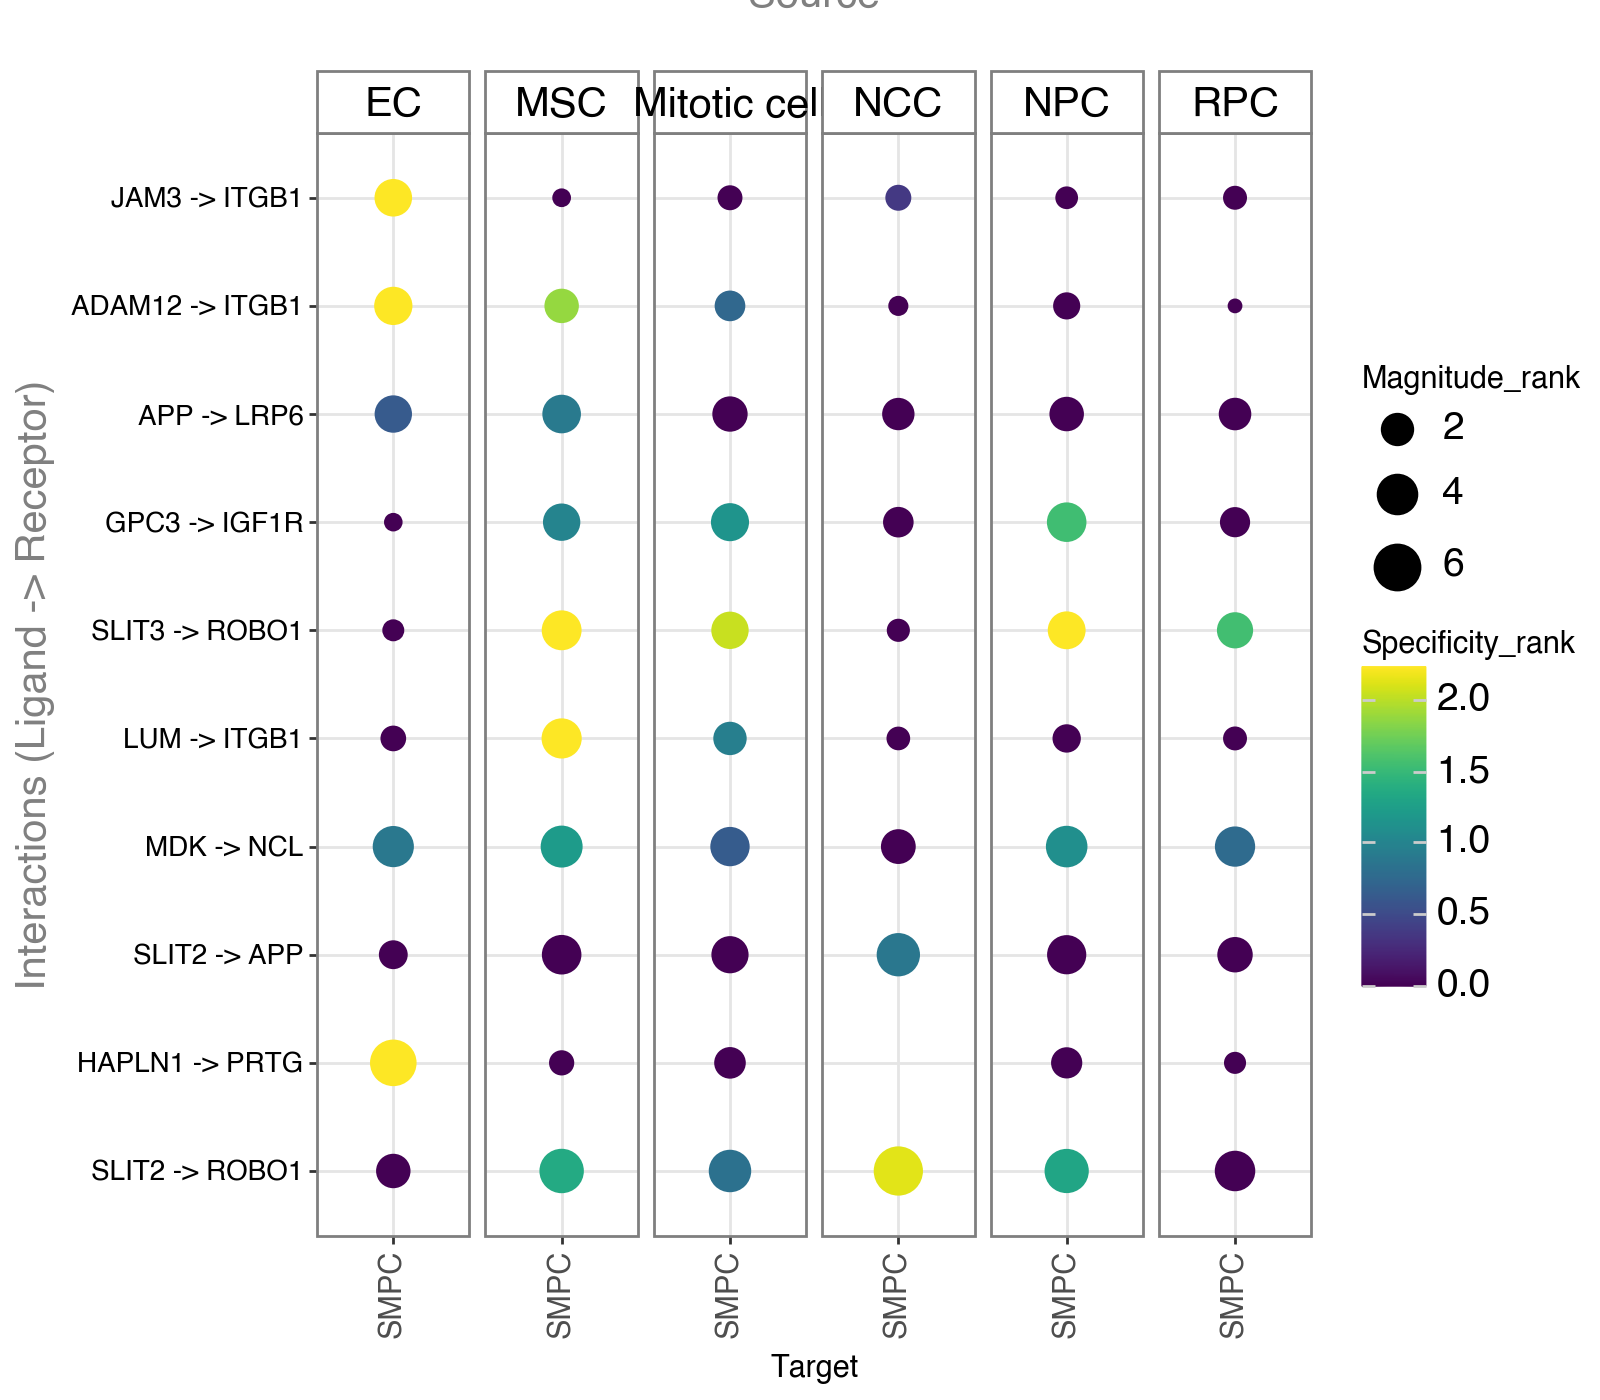

In [18]:
# DOTPLOT shows the most 'relevant' interactions ordered to the magnitude rank results from the aggregated rank.
li.pl.dotplot(adata = adata, 
              colour='specificity_rank',
              size='magnitude_rank',
              inverse_size=True,
              inverse_colour=True,
              source_labels=['EC', 'Mitotic cell', 'NPC', 'NCC', 'RPC', 'MSC'],
              target_labels=['SMPC'],
              top_n=10, 
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(8, 7)
             )

In [ ]:
#### for bottom graph

#Every interaction row is evaluated independently

#Any interaction in the top 1% of specificity is plotted

#No control over how many ligand–receptor types appear

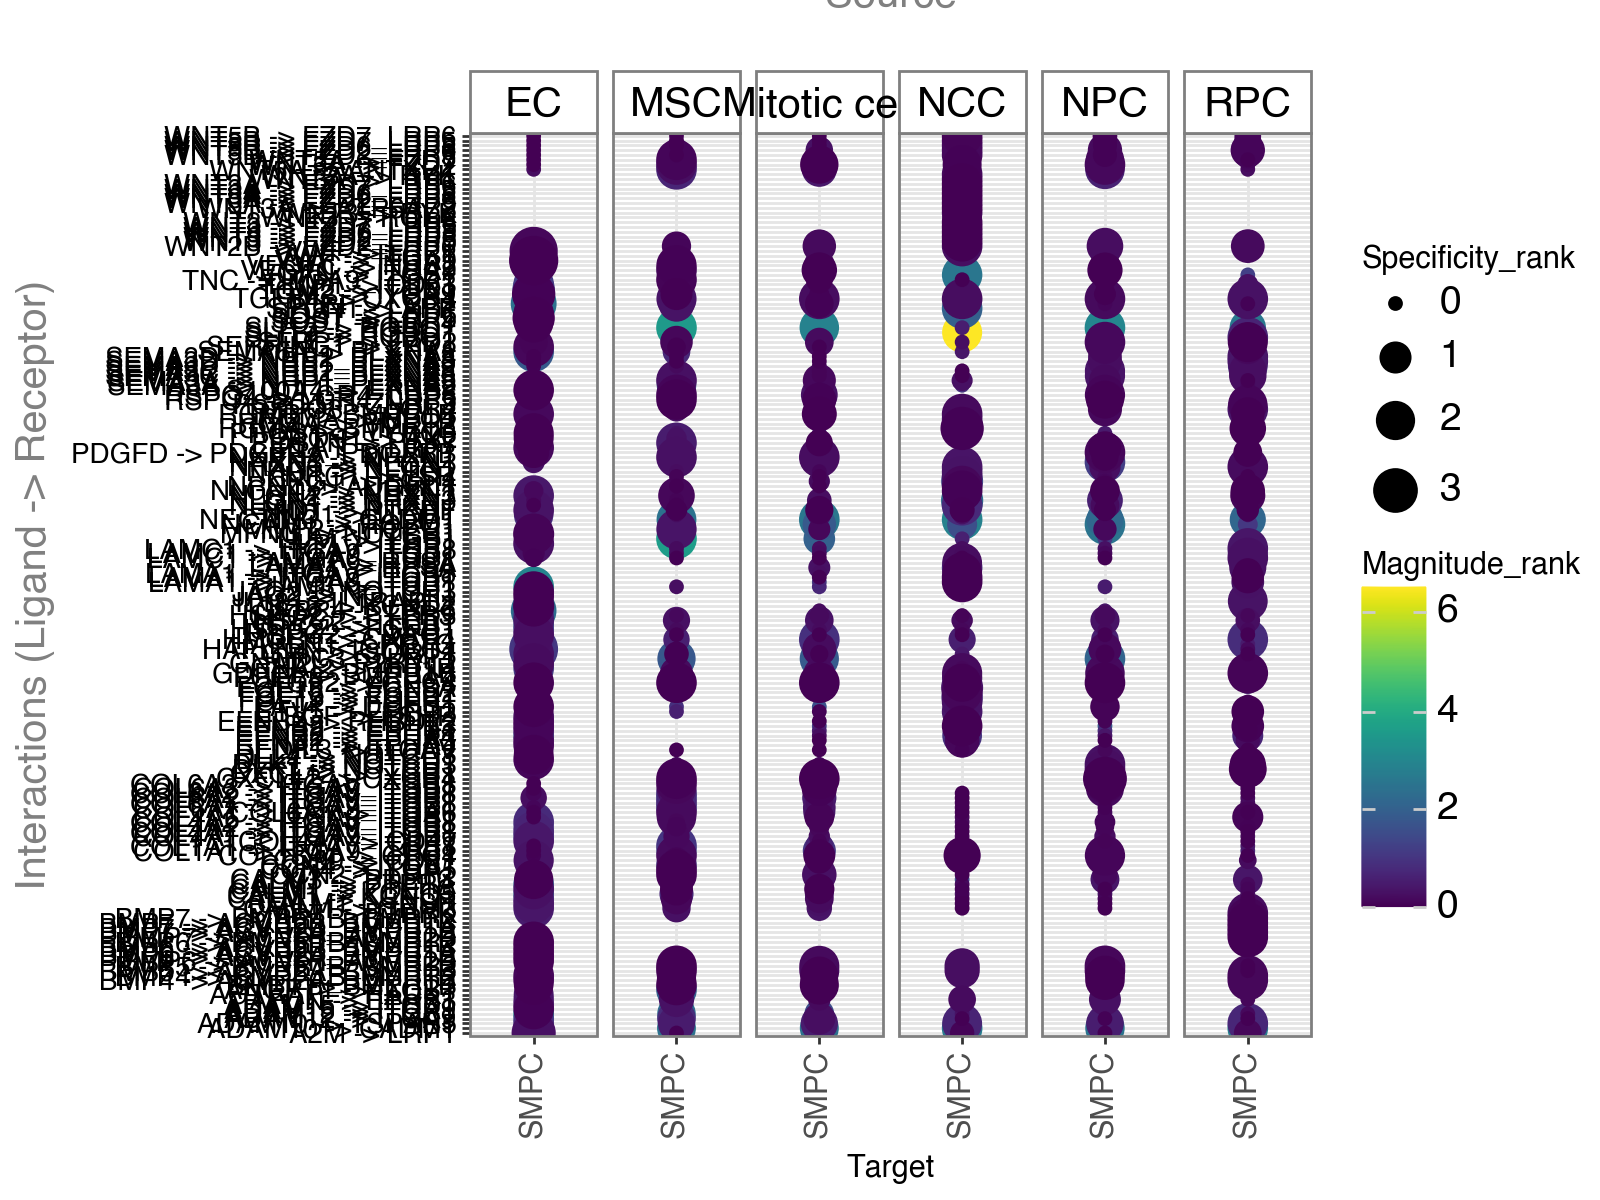

In [19]:
## we can also treat the ranks provided by RRA as a probability distribution to which we can filter interactions according to how 
## robustly and highly ranked they are across the different methods
my_plot = li.pl.dotplot(adata = adata, 
                        colour='magnitude_rank',
                        inverse_colour=True,
                        size='specificity_rank',
                        inverse_size=True,
                        source_labels=['EC', 'Mitotic cell', 'NPC', 'NCC', 'RPC', 'MSC'],
                        target_labels=['SMPC'],
                        filter_fun=lambda x: x['specificity_rank'] <= 0.01,
                       )
my_plot

In [ ]:
# make the plot readable

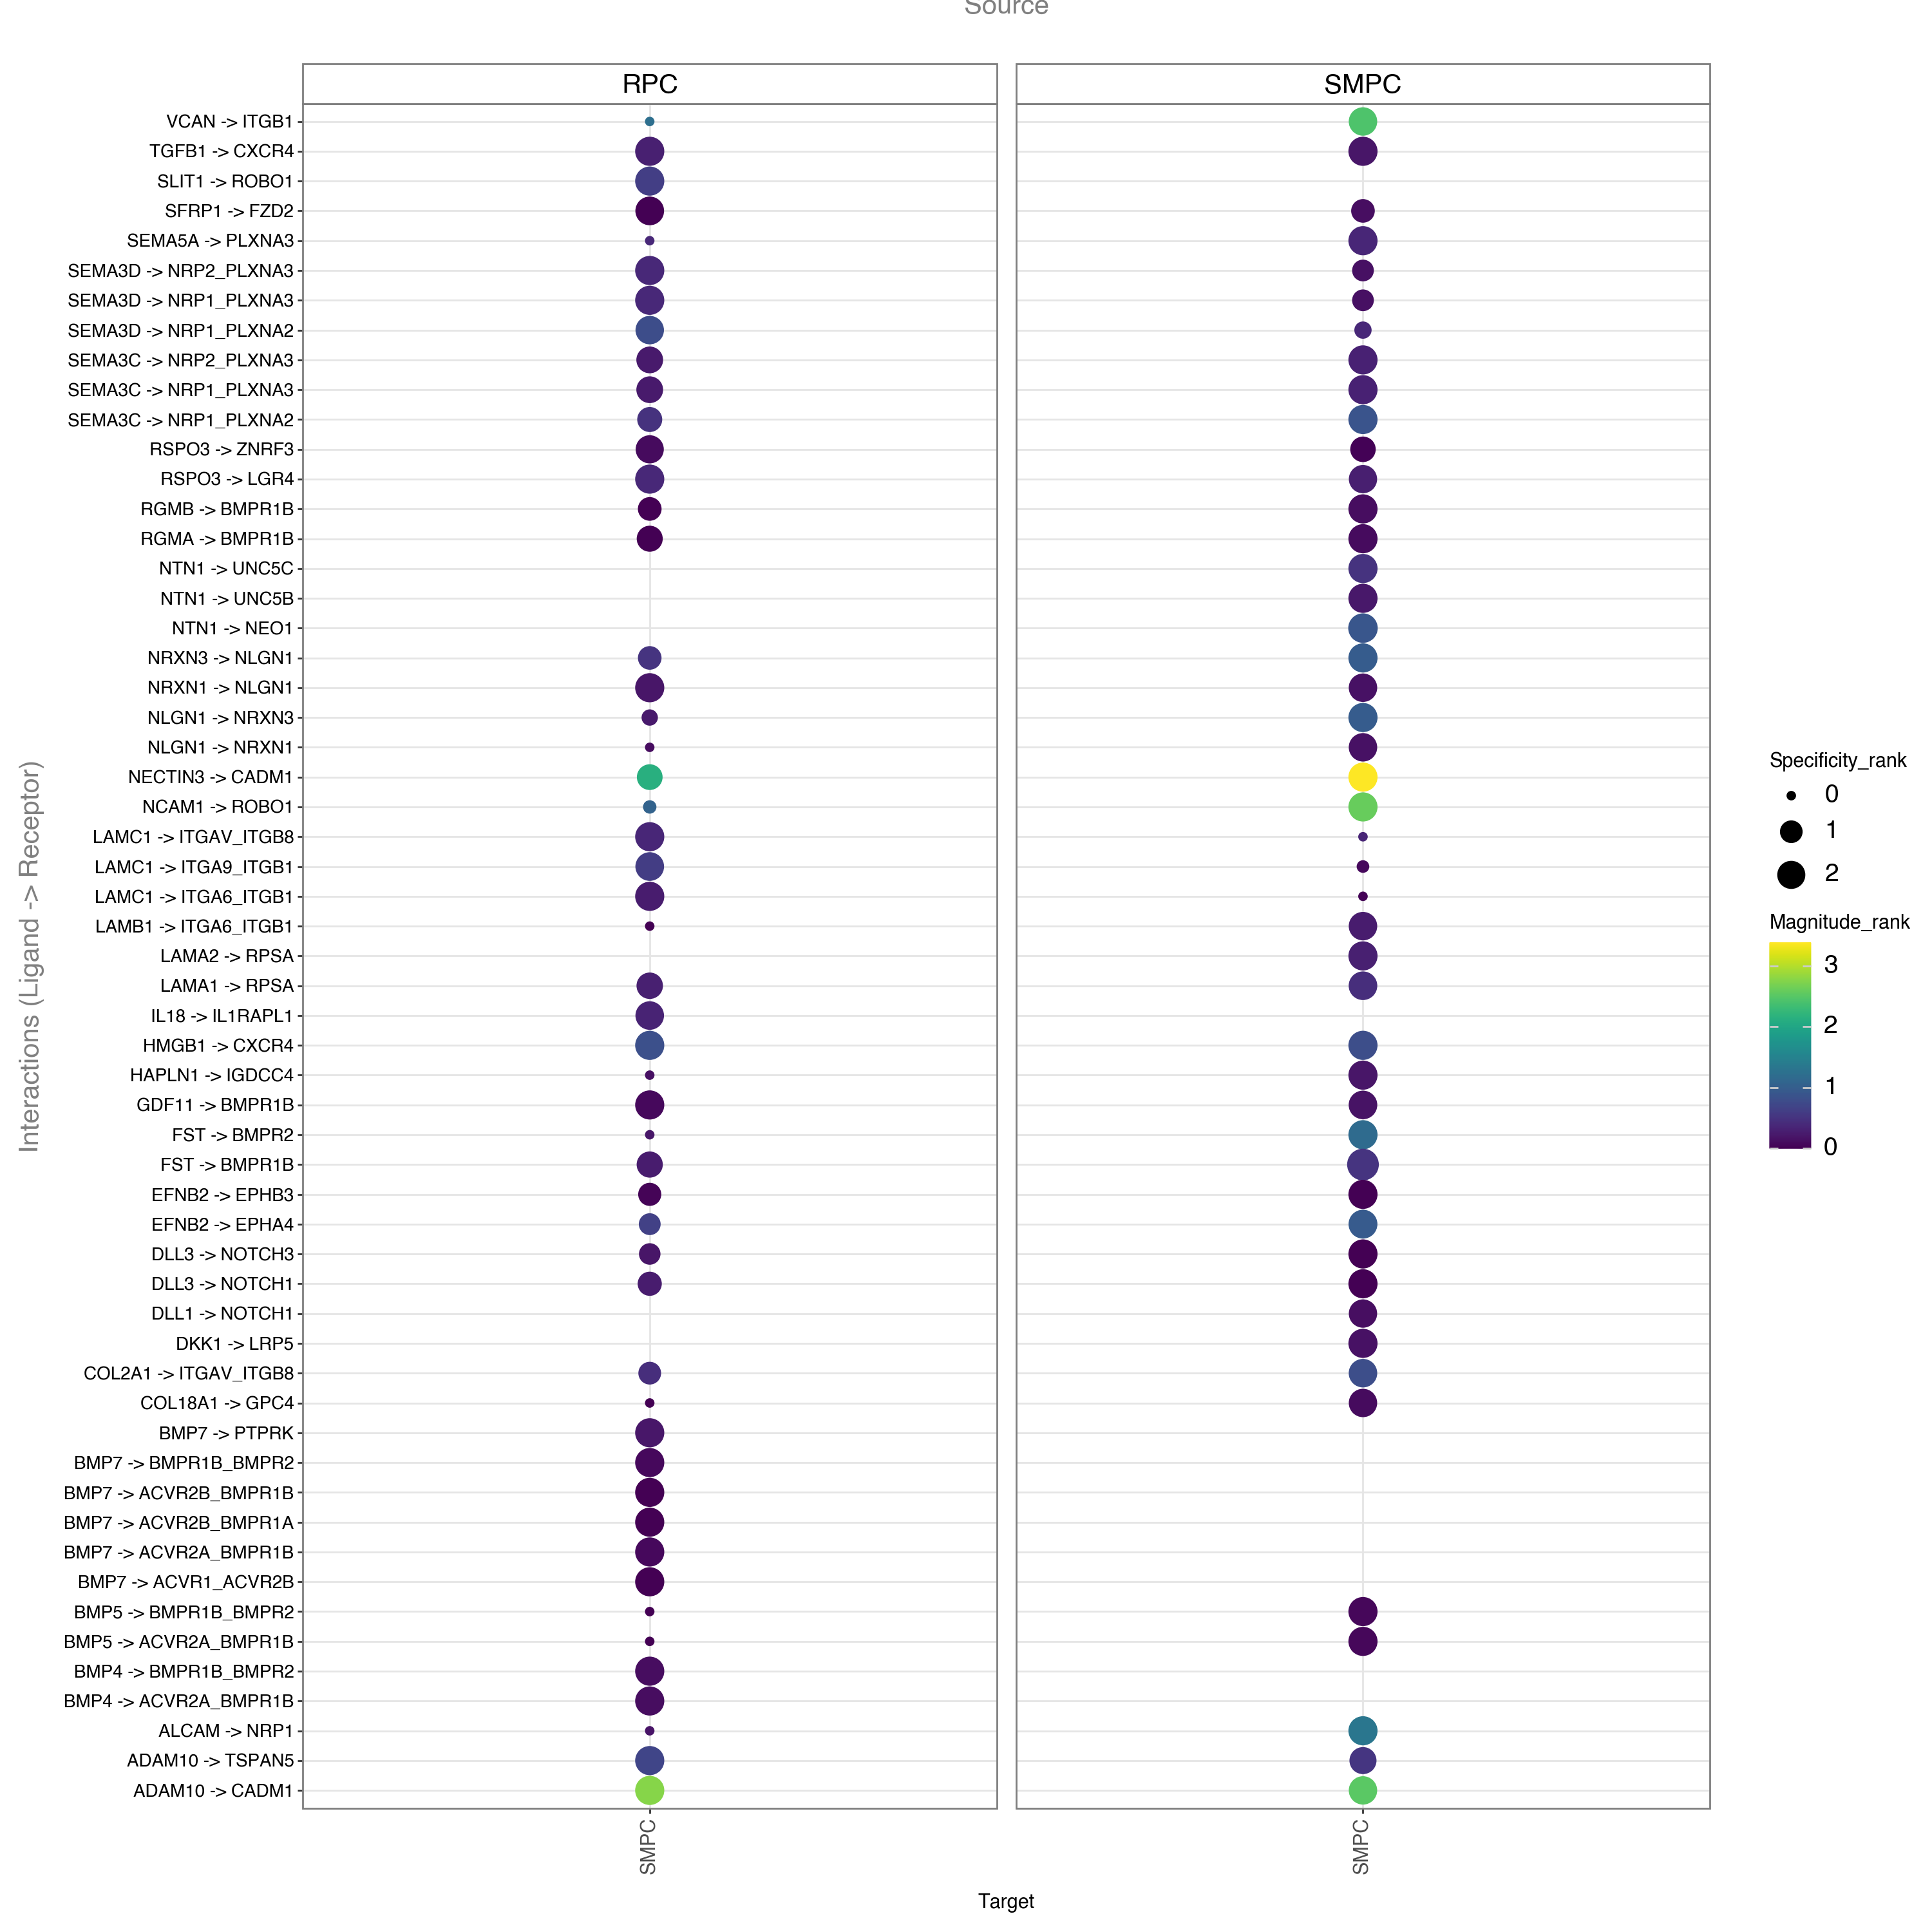

In [20]:
my_plot = li.pl.dotplot(adata = adata, 
                        colour='magnitude_rank',
                        inverse_colour=True,
                        size='specificity_rank',
                        inverse_size=True,
                        source_labels=['RPC', 'SMPC'],
                        target_labels=['SMPC'],
                        filter_fun=lambda x: x['specificity_rank'] <= 0.01,
                        figure_size=(15, 15),
                       )
my_plot

In [ ]:
# this one shows the ‘relevant’ interactions ordered to the magnitude_rank results from aggregated_rank.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


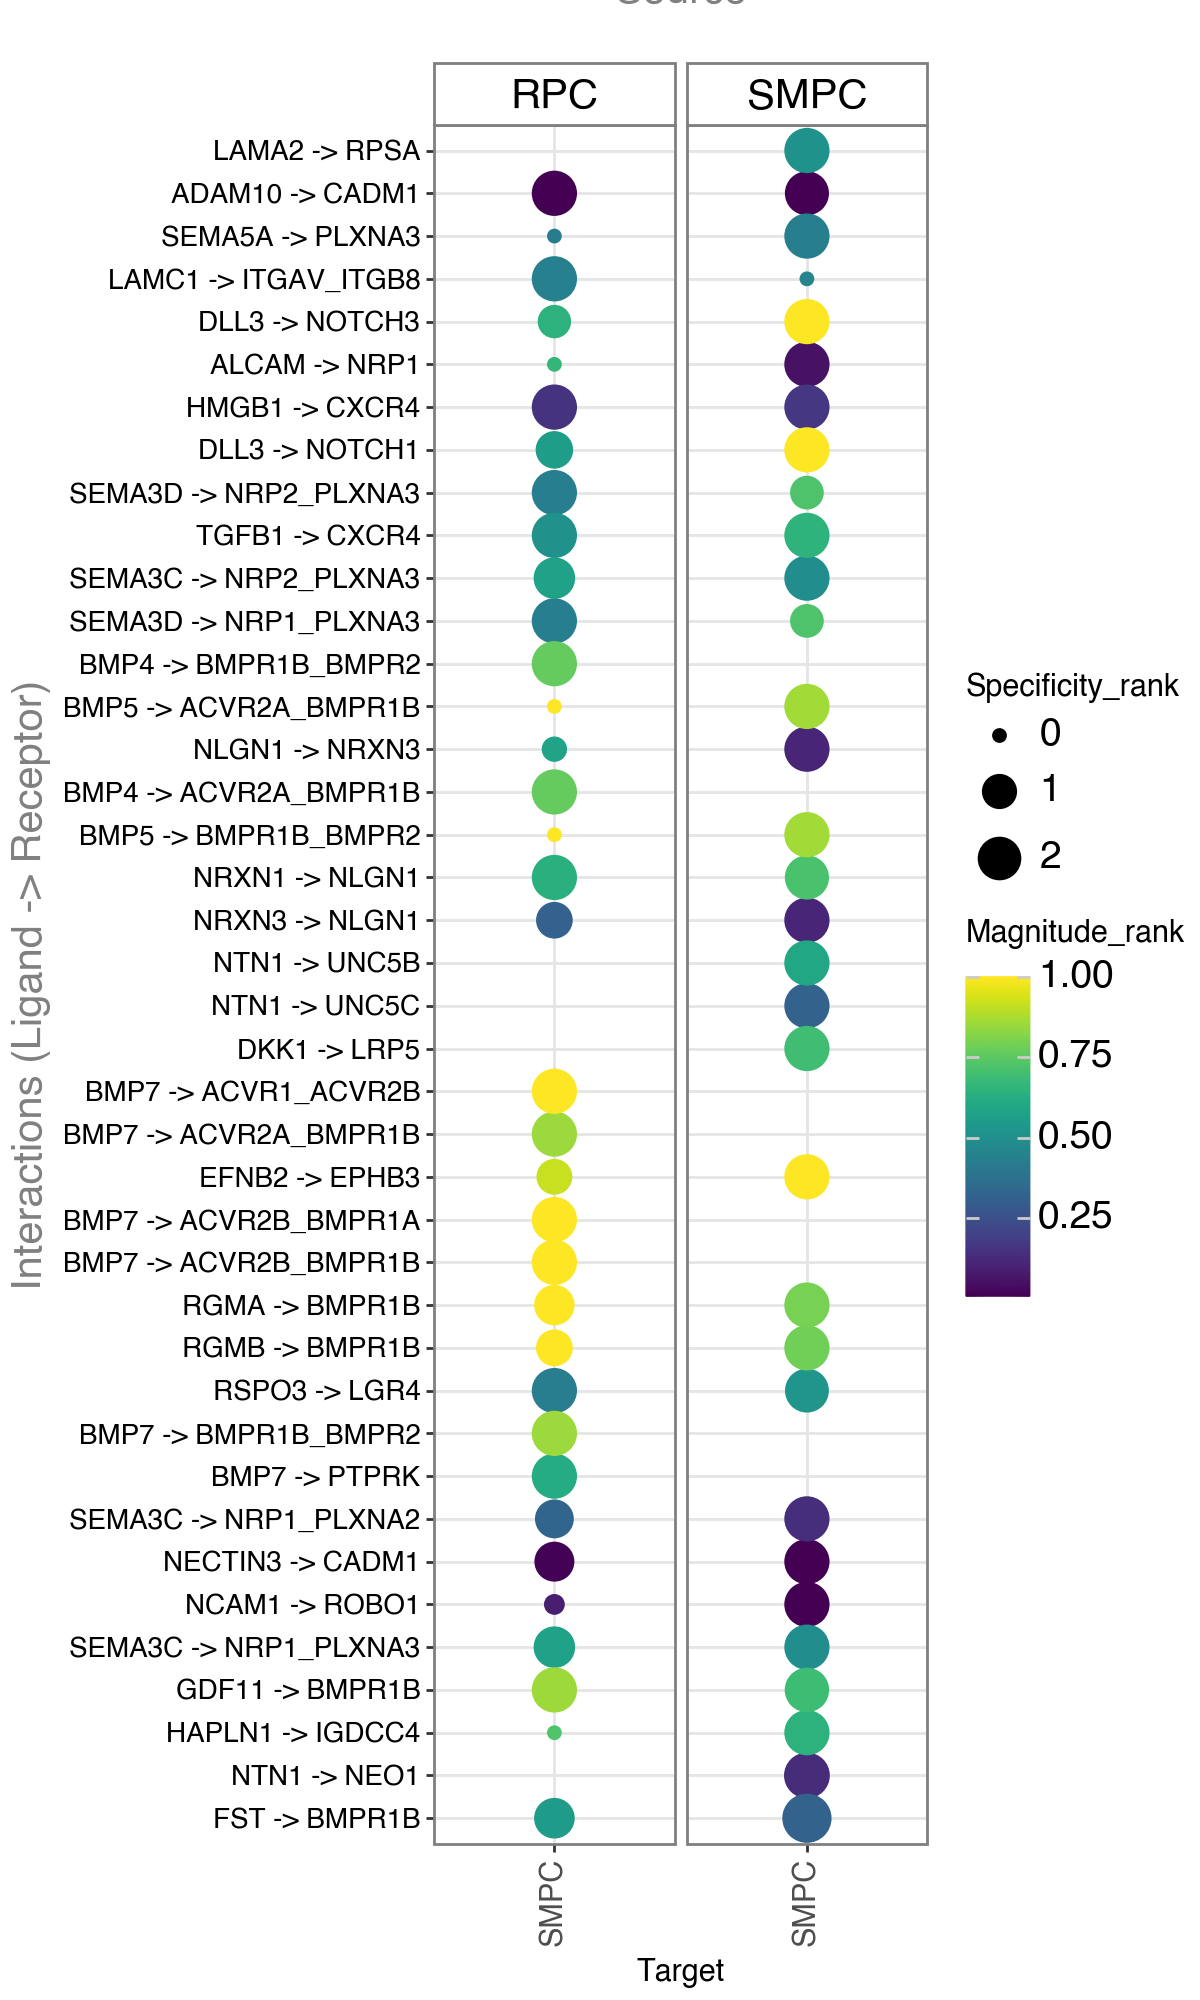

In [113]:
li.pl.dotplot(adata = adata, 
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=False,
              source_labels=['RPC', 'SMPC'],
              target_labels=['SMPC'],
              top_n=40, 
              orderby='specificity_rank',
              orderby_ascending=True,
              figure_size=(6, 10)
             )

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


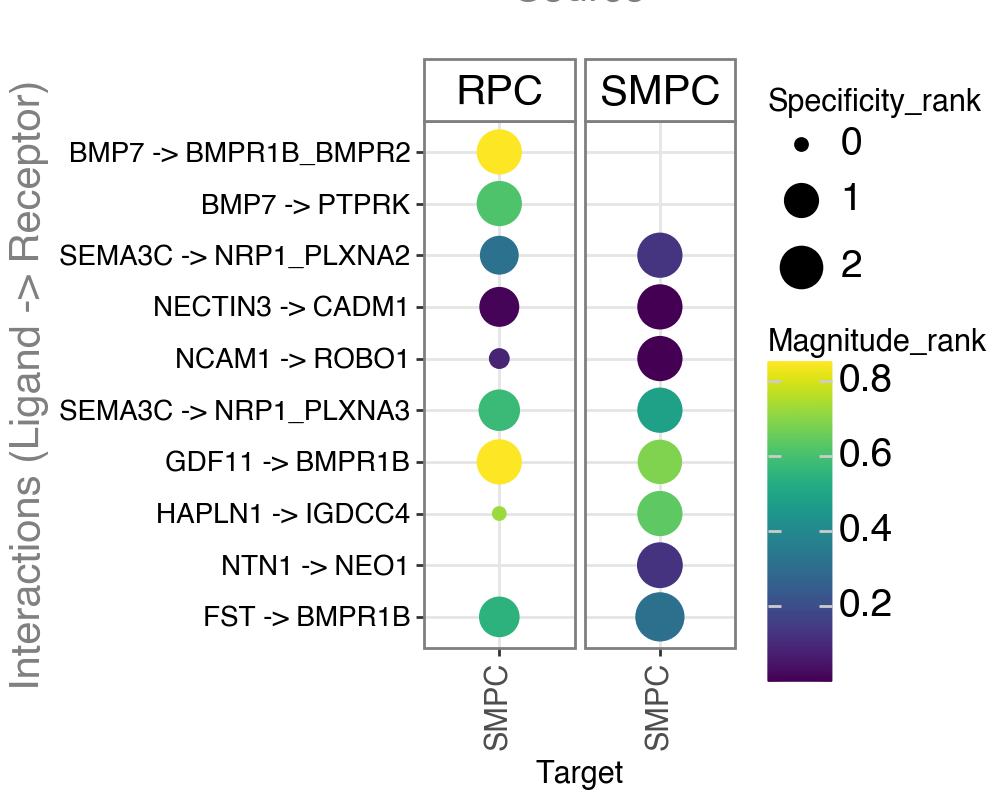

In [128]:
li.pl.dotplot(adata = adata, 
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=False,
              source_labels=['RPC', 'SMPC'],
              target_labels=['SMPC'],
              top_n=10, 
              orderby='specificity_rank',
              orderby_ascending=True,
              figure_size=(5,4)
             )

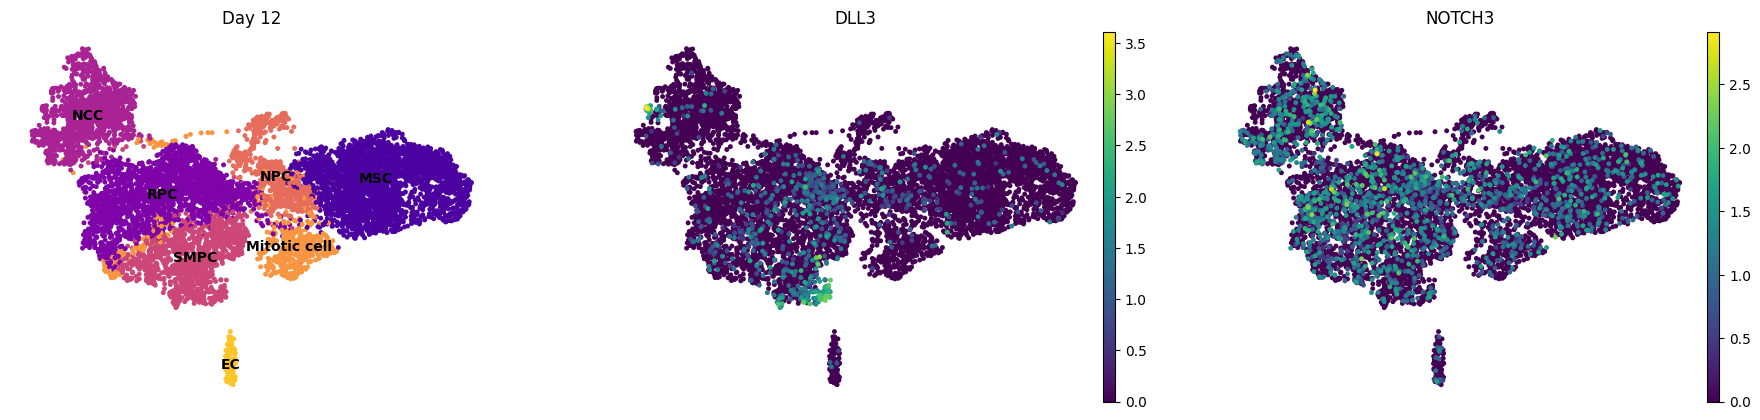

In [129]:
sc.pl.umap(adata, color=['celltype','DLL3', 'NOTCH3'], title='Day 12', frameon=False, legend_loc='on data', s=50)

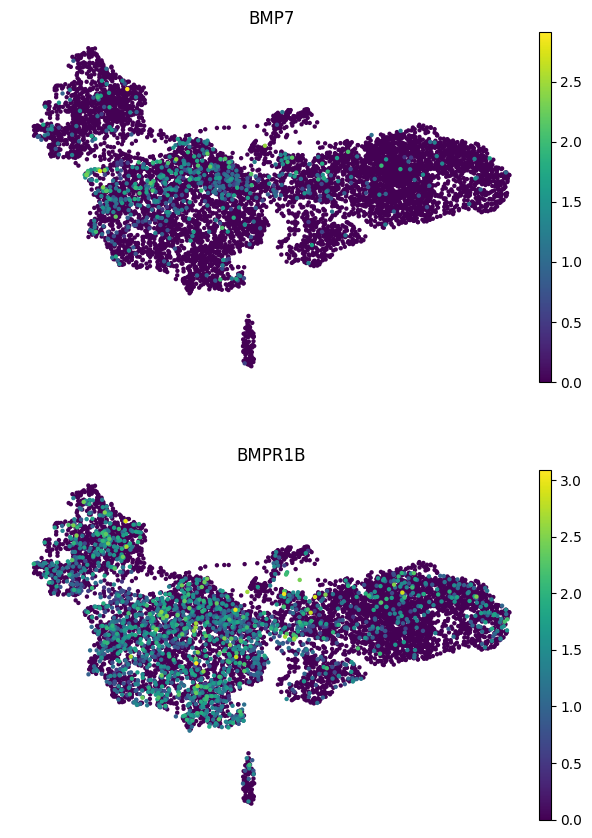

In [151]:
sc.pl.umap(adata, color=['BMP7', 'BMPR1B'], frameon=False, legend_loc='on data', s=40, ncols=1)
import matplotlib.pyplot as plt

plt.rcParams['legend.fontsize'] = 20  

In [144]:
# save analysis
adata.write("/Users/ogjaime/Desktop/CellRank/krabd12/LIANA/krabd12_LIANA.h5ad")

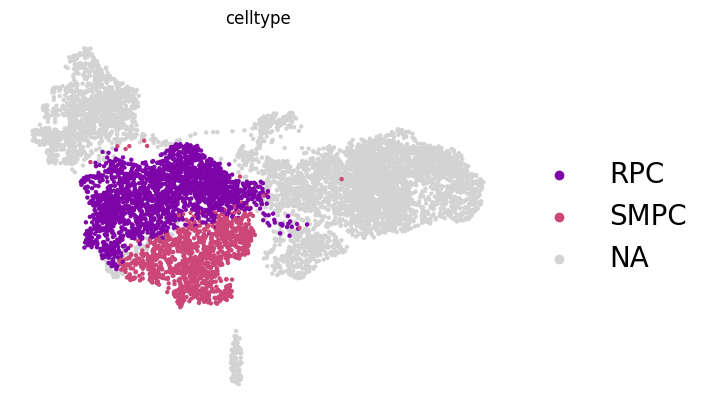

In [152]:
## outline cells of interest
ax = sc.pl.umap(
    adata,
    color="celltype",      # NOT a list
    groups=["SMPC", "RPC"],
    frameon=False,
    s=40,
    show=False
)
import matplotlib.pyplot as plt
plt.show()


In [ ]:
#### continue analysis

In [2]:
## loading packages
# import liana
import liana as li
# needed for visualization and toy data
import scanpy as sc

In [23]:
adata1 = sc.read_h5ad("/Users/ogjaime/Desktop/CellRank/krabd28/LIANA/krabd28_LIANA.h5ad")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


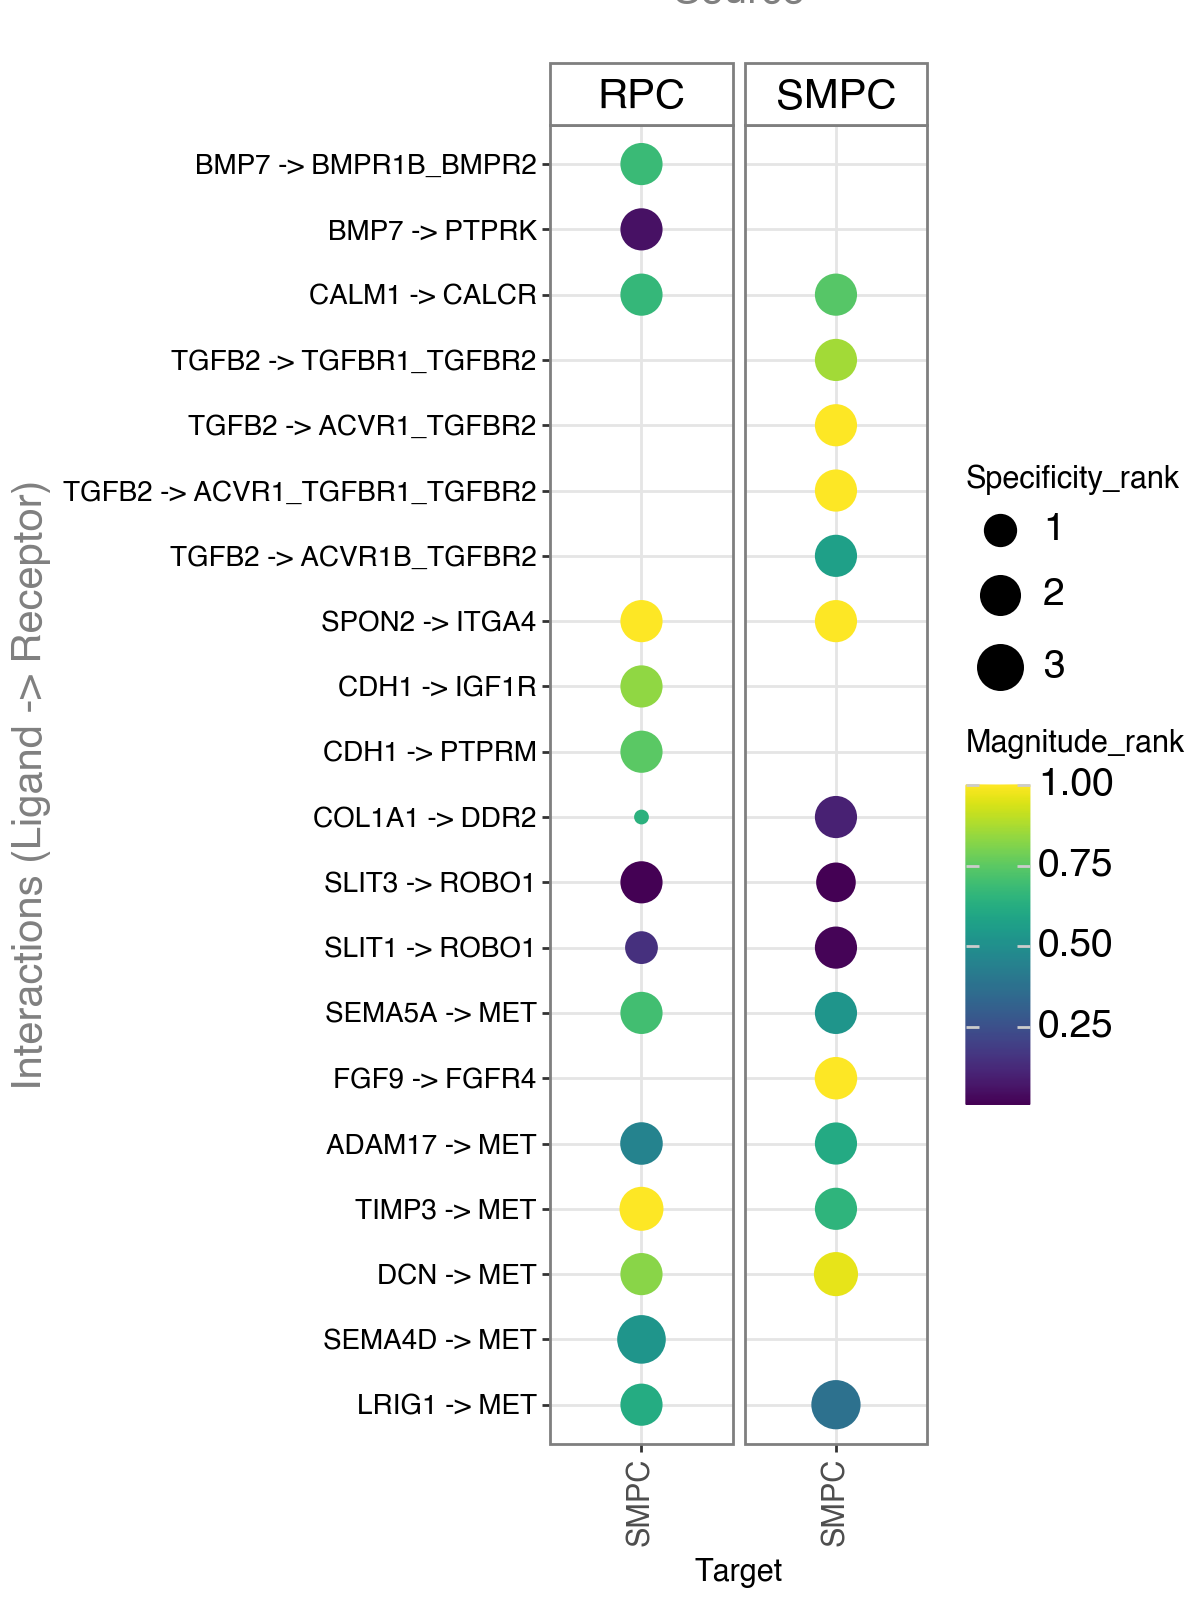

In [24]:
li.pl.dotplot(adata = adata1, 
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=False,
              source_labels=['RPC', 'SMPC'],
              target_labels=['SMPC'],
              top_n=20, 
              orderby='specificity_rank',
              orderby_ascending=True,
              figure_size=(6,8)
             )

In [ ]:
sc.pl.umap(adata, color=['BMP7', 'BMPR1B'], frameon=False, legend_loc='on data', s=40, ncols=1)
import matplotlib.pyplot as plt

plt.rcParams['legend.fontsize'] = 20  